# Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
import lightgbm as lgb
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import re

# Load the Data

In [2]:
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')
sample= pd.read_csv('data/sample.csv')

train = train.drop(columns=['post_id'])
test = test.drop(columns=['post_id'])

# EDA

**EDA ON WHOLE DATASET**

In [3]:
print(train.head())

                       created_date  emoticon_1  emoticon_2  emoticon_3  \
0  2024-01-18 08:43:57.397508+00:00           0           0           0   
1  2024-03-24 21:43:11.490017+00:00           0           0           0   
2  2024-04-24 20:32:17.014931+00:00           0           1           1   
3  2023-05-28 22:00:14.214527+00:00           0           0           0   
4  2023-09-09 23:12:05.689498+00:00           0           0           0   

   upvote  downvote  if_1  if_2 race religion gender  disability  \
0       0         1     0    10  NaN      NaN    NaN       False   
1       6         0     0     4  NaN      NaN    NaN       False   
2       0         0     0    10  NaN      NaN    NaN       False   
3       5         0     0    10  NaN      NaN    NaN       False   
4       0         0     0    10  NaN      NaN    NaN       False   

                                             comment  label  
0  She might be a bright spot for a party keou on...      2  
1  Under Alaska 

label
0    0.576631
2    0.315354
1    0.080394
3    0.027621
Name: proportion, dtype: float64


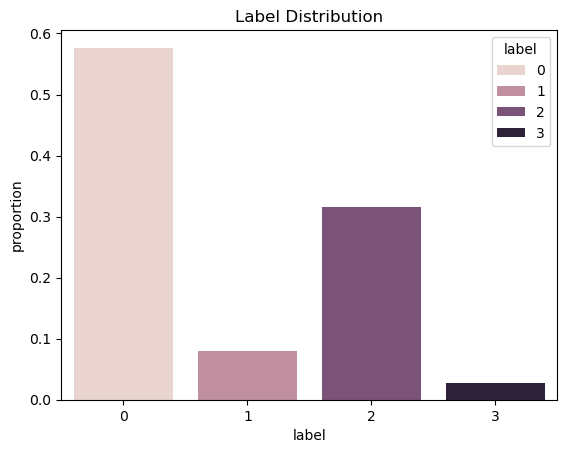

In [4]:
# label distribution

print(train['label'].value_counts(normalize=True))

l = train['label'].value_counts(normalize=True).reset_index()
sns.barplot(data=l, x='label', y='proportion', hue='label')
plt.title('Label Distribution')
plt.show()

**Dataset is highly imbalanced with almost 90 percent comprising of classes 0 and 2**

In [5]:
print(train.describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]))

          emoticon_1     emoticon_2     emoticon_3         upvote  \
count  198000.000000  198000.000000  198000.000000  198000.000000   
mean        0.279768       0.048338       0.121071       2.607975   
std         1.023234       0.258477       0.481013       5.054763   
min         0.000000       0.000000       0.000000       0.000000   
25%         0.000000       0.000000       0.000000       0.000000   
50%         0.000000       0.000000       0.000000       1.000000   
75%         0.000000       0.000000       0.000000       3.000000   
95%         2.000000       0.000000       1.000000      10.000000   
99%         4.000000       1.000000       2.000000      22.000000   
max        47.000000      11.000000      17.000000     201.000000   

            downvote           if_1           if_2          label  
count  198000.000000  198000.000000  198000.000000  198000.000000  
mean        0.666394       1.906152       7.956212       0.793965  
std         2.044335      25.635752 

**Each numeric Feature here Represents Count and Each of Them are right skewed. There are Outliers in each of them It can be a signal instead of a noise.**

- Most samples belong to lower classes (especially 0), making the dataset highly imbalanced.
- Upvotes and downvotes follow a long-tail distribution with few highly popular posts.
- keeping them is not a bad idea.

In [6]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   created_date  198000 non-null  str  
 1   emoticon_1    198000 non-null  int64
 2   emoticon_2    198000 non-null  int64
 3   emoticon_3    198000 non-null  int64
 4   upvote        198000 non-null  int64
 5   downvote      198000 non-null  int64
 6   if_1          198000 non-null  int64
 7   if_2          198000 non-null  int64
 8   race          52577 non-null   str  
 9   religion      52577 non-null   str  
 10  gender        52577 non-null   str  
 11  disability    198000 non-null  bool 
 12  comment       197999 non-null  str  
 13  label         198000 non-null  int64
dtypes: bool(1), int64(8), str(5)
memory usage: 19.8 MB


In [7]:
numeric_cols = train.select_dtypes('int64').columns
categorical_cols = train.select_dtypes('str').columns
binary_cols = train.select_dtypes('bool').columns

print('Numeric Columns')
print(numeric_cols)
print("\n Categorical Cols")
print(categorical_cols)
print("\n Binary Columns")
print(binary_cols)

Numeric Columns
Index(['emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1',
       'if_2', 'label'],
      dtype='str')

 Categorical Cols
Index(['created_date', 'race', 'religion', 'gender', 'comment'], dtype='str')

 Binary Columns
Index(['disability'], dtype='str')


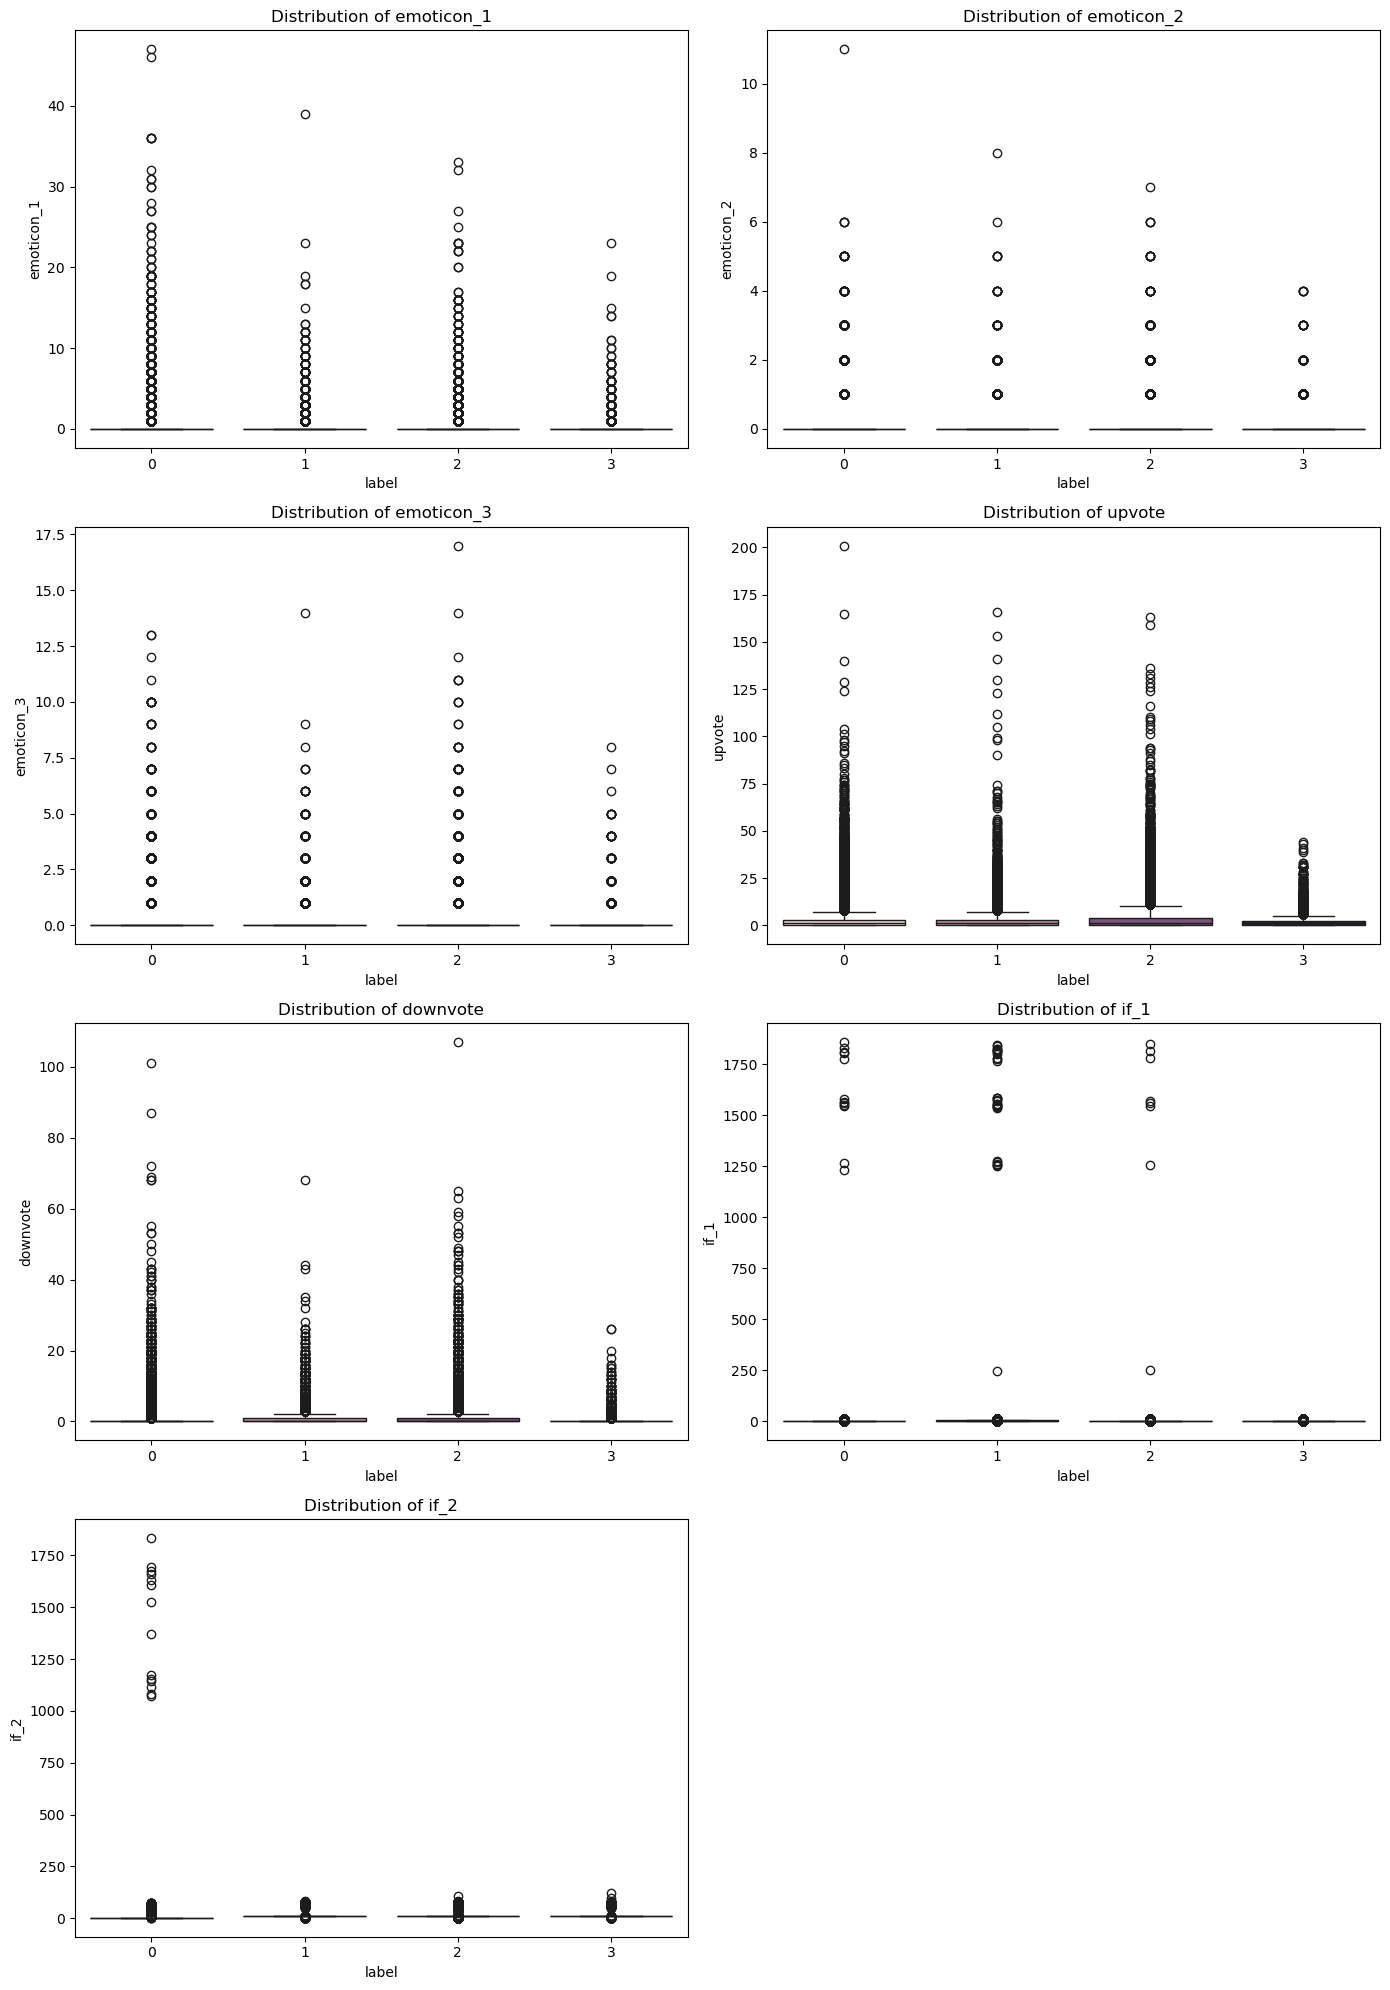

In [8]:
cols = [col for col in numeric_cols if col != 'label']
n = len(cols)
fig, axes = plt.subplots(nrows=(n + 1) // 2, ncols=2, figsize=(14, 5 * ((n + 1) // 2)))
axes = axes.flatten()

for idx, col in enumerate(cols):
    sns.boxplot(data=train, x='label', y=col, ax=axes[idx], hue='label', legend=False)
    axes[idx].set_title(f'Distribution of {col}')

# Hide any unused subplots
for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

**From the Image It can be clearly seen that the Outliers of if_1 and if_2 are signals. Other feature's Outliers don't represent Strong signal**

## Exploring Categorical Features

In [9]:
for col in ['race', 'religion', 'gender']:
    print(f'{col} value counts:')
    print(train[col].value_counts())
    print()

race value counts:
race
none      39682
white      5486
black      3869
other      1654
asian      1263
latino      623
Name: count, dtype: int64

religion value counts:
religion
none         38249
christian     7191
muslim        4930
jewish        1244
other          547
atheist        219
buddhist       100
hindu           97
Name: count, dtype: int64

gender value counts:
gender
none           36161
female          8037
male            7549
transgender      622
other            208
Name: count, dtype: int64



In [10]:
train[binary_cols].value_counts()

disability
False         195257
True            2743
Name: count, dtype: int64

# Feature Extraction

## Create date time features

In [11]:
def create_datetime_features(df):
    df['year'] = df['created_date'].dt.year
    df['month'] = df['created_date'].dt.month
    df['day'] = df['created_date'].dt.day
    df['dayofweek'] = df['created_date'].dt.dayofweek
    df['quarter'] = df['created_date'].dt.quarter
    df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)
    return df

In [12]:
train['created_date'] = pd.to_datetime(train.created_date)
test['created_date'] = pd.to_datetime(test.created_date)

train = create_datetime_features(train)
test = create_datetime_features(test)

# drop the created_date column
train = train.drop('created_date', axis=1)
test = test.drop('created_date', axis=1)

## Text cleaning and Text Features

In [13]:
# a function for cleaning the text data
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '<link>', text) # this removes the http links
    text = re.sub(r'www\.\S+', '<link>', text) # this removes the www links
    text = re.sub(r'https\S+', '<link>', text) # this removes the https links
    text = re.sub(r'\S+@\S+', '<email>', text) # this removes the email addresses
    text = re.sub(r'\d+\S+', '<number>', text) # this removes the numbers
    text = re.sub(' +', ' ', text)
    return text

# dropna values before cleaning the text data
train = train.dropna(subset=['comment'])
test = test.dropna(subset=['comment'])

# apply the function to X_small and test data
train['comment_clean'] = train['comment'].apply(clean_text)
test['comment_clean'] = test['comment'].apply(clean_text)

In [14]:
for i in range(2):
    print(f'Original comment {i}:')
    print(train.comment[i])
    print(f'Cleaned comment {i}:')
    print(train.comment_clean[i])
    print()

Original comment 0:
She might be a bright spot for a party keou on Oahu dominated by greedy criminals or ethically challenged individuals.
Cleaned comment 0:
she might be a bright spot for a party keou on oahu dominated by greedy criminals or ethically challenged individuals.

Original comment 1:
Under Alaska law, a non-tribal member is not bound to tribal court.. Living in a particular community does not change your rights under state and federal law. In this case, Connor can basically flip the bird to the tribal court and there's nothing they can actually do. The only courts it appears he is subject to are those formally established under state and federal law, which does not recognize this.

The tribal court can at-best basically use it's influence to get tribal members and others in the community to refuse to associate with Connor and not do business with him, essentially acting like a shunning until Connor decides to leave.
Cleaned comment 1:
under alaska law, a non-tribal member 

## Additional Text Features

In [15]:
# more textual features
def add_text_features(df):
    df['comment_len'] = df['comment'].str.len()
    df['comment_word_count'] = df['comment'].str.split().str.len().fillna(0)
    df['comment_avg_word_len'] = df['comment_len'] / (df['comment_word_count'] + 1)
    df['comment_upper_ratio'] = df['comment'].str.count(r'[A-Z]') / (df['comment_len'] + 1)
    df['comment_exclamation_count'] = df['comment'].str.count('!')
    df['comment_question_count'] = df['comment'].str.count(r'\?')
    df['comment_punct_count'] = df['comment'].str.count(r'[^\w\s]')
    df['comment_punct_ratio'] = df['comment_punct_count'] / (df['comment_len'] + 1)
    return df


In [16]:
train = add_text_features(train)
test = add_text_features(test)

## Create Val and Train set

In [17]:
X_full = train.drop(columns=['label', 'comment'])
y_full = train['label']

X_train, X_val, y_train, y_val = train_test_split(X_full, y_full, test_size=0.2, random_state=42, stratify=y_full)

print(X_train.shape)
print(X_val.shape)
print(y_train.shape)
print(y_val.shape)

print("Train label distribution")
print(y_train.value_counts() / len(y_train) * 100)

print("Validation label distribution")
print(y_val.value_counts() / len(y_val) * 100)

(158399, 26)
(39600, 26)
(158399,)
(39600,)
Train label distribution
label
0    57.663243
2    31.535553
1     8.039192
3     2.762012
Name: count, dtype: float64
Validation label distribution
label
0    57.661616
2    31.535354
1     8.040404
3     2.762626
Name: count, dtype: float64


In [18]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 158399 entries, 180416 to 66216
Data columns (total 26 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   emoticon_1                 158399 non-null  int64  
 1   emoticon_2                 158399 non-null  int64  
 2   emoticon_3                 158399 non-null  int64  
 3   upvote                     158399 non-null  int64  
 4   downvote                   158399 non-null  int64  
 5   if_1                       158399 non-null  int64  
 6   if_2                       158399 non-null  int64  
 7   race                       41936 non-null   str    
 8   religion                   41936 non-null   str    
 9   gender                     41936 non-null   str    
 10  disability                 158399 non-null  bool   
 11  year                       158399 non-null  int32  
 12  month                      158399 non-null  int32  
 13  day                        158399 non-nul

In [19]:
bin_feature = X_train.select_dtypes('bool').columns
numeric_features = X_train.select_dtypes(include=['float32', 'float64', 'int32', 'int64']).columns
categorical_features = list(X_train.select_dtypes(include='str').columns)
categorical_features.remove('comment_clean')
text_feature = ['comment_clean']

print(f'Categorical Featurs: {len(categorical_features)}, Numerical features: {len(numeric_features)}, bin features: {len(bin_feature)}')
print('total features', X_train.shape[1])

Categorical Featurs: 3, Numerical features: 21, bin features: 1
total features 26


## Preprocessing Pipeline

In [20]:
X_train['disability'] = X_train['disability'].astype('int')
X_val['disability'] = X_val['disability'].astype('int')


tfidf = TfidfVectorizer(
    max_features=15000,
    stop_words='english',
    lowercase=True,
    min_df=2,
    ngram_range=(1,2),
    max_df=0.98,
    sublinear_tf=True
)

tfidf_char = TfidfVectorizer(
    max_features=15000,
    lowercase=True,
    analyzer='char_wb',
    min_df=3,
    max_df=0.95,
    ngram_range=(3,5),
    sublinear_tf=True
)

scaler = StandardScaler()

tfidf_transformer = FeatureUnion([
    ('word', tfidf),
    ('char', tfidf_char)
])

reduce_tfidf = Pipeline([
    ('tfidf', tfidf_transformer),
    ('truncate', TruncatedSVD(n_components=1000))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=True,))
])

preprocessor = ColumnTransformer([
    ('num', scaler, numeric_features),
    ('cat', categorical_transformer, categorical_features),
    ('text', reduce_tfidf, 'comment_clean')
], remainder='passthrough')


### Classifier

In [21]:
def evaluate(model, X_train, y_train, X_val, y_val, train=False):
    if train:
        model.fit(X_train, y_train)
    
    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)

    weight_train = (train_pred != y_train)
    weight_val = (val_pred != y_val)
    
    print('Train Classification Report:')
    ConfusionMatrixDisplay.from_predictions(y_train, train_pred, normalize="true", values_format=".0%")
    plt.title('Confusion matrix Normalized by Row')
    plt.show()
    ConfusionMatrixDisplay.from_predictions(y_train, train_pred, normalize="true", values_format=".0%", sample_weight=weight_train)
    plt.title('Errors Normalized by Row')
    plt.show()
    
    print(classification_report(y_train, train_pred))
    print("\n")
    print('Validation Classification Report:')
    ConfusionMatrixDisplay.from_predictions(y_val, val_pred, normalize="true", values_format=".0%")
    plt.title('Confusion matrix Normalized by Row')
    plt.show()    
    ConfusionMatrixDisplay.from_predictions(y_val, val_pred, normalize="true", values_format=".0%", sample_weight=weight_val)
    plt.title('Errors Normalized by Row')
    plt.show()
    print(classification_report(y_val, val_pred))

In [22]:
print('Before Transformation:', (X_train.shape, X_val.shape))
X_train_transformed = preprocessor.fit_transform(X_train)
X_val_transformed = preprocessor.transform(X_val)
print('After Transformation:', (X_train_transformed.shape, X_val_transformed.shape))

Before Transformation: ((158399, 26), (39600, 26))
After Transformation: ((158399, 1041), (39600, 1041))


Train Classification Report:


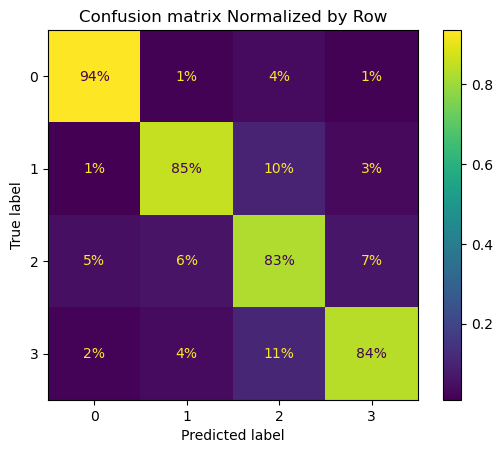

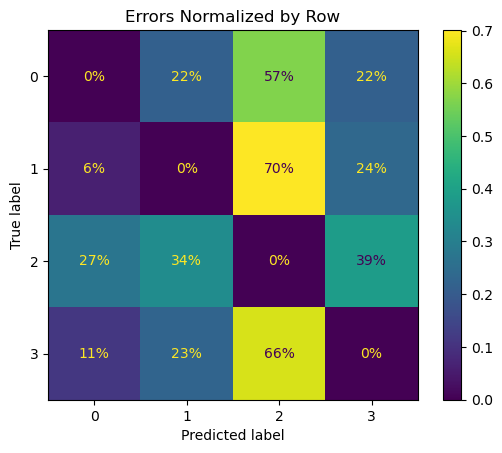

              precision    recall  f1-score   support

           0       0.97      0.94      0.95     91338
           1       0.71      0.85      0.78     12734
           2       0.89      0.83      0.86     49952
           3       0.42      0.84      0.56      4375

    accuracy                           0.89    158399
   macro avg       0.75      0.86      0.79    158399
weighted avg       0.91      0.89      0.90    158399



Validation Classification Report:


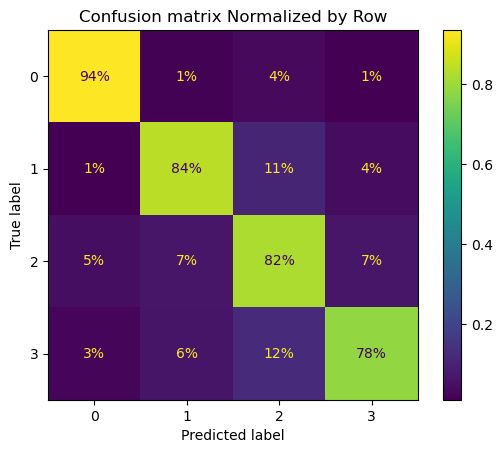

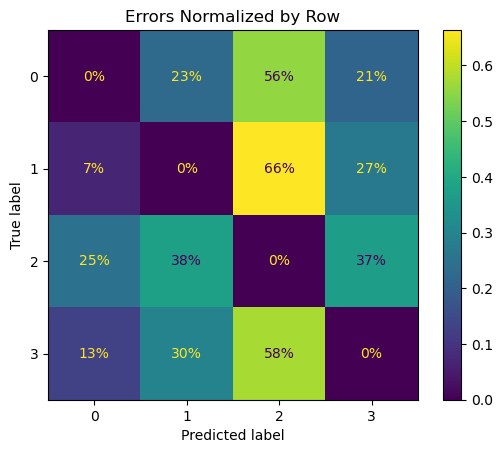

              precision    recall  f1-score   support

           0       0.97      0.94      0.95     22834
           1       0.68      0.84      0.75      3184
           2       0.89      0.82      0.85     12488
           3       0.40      0.78      0.53      1094

    accuracy                           0.89     39600
   macro avg       0.74      0.85      0.77     39600
weighted avg       0.91      0.89      0.89     39600



In [23]:
classifier = LogisticRegression(
    C = 1.09,
    solver='lbfgs',
    max_iter=300,
    class_weight={0: 1, 1: 3, 2: 1, 3: 8},
    l1_ratio=0,
    verbose=1
)

evaluate(classifier, X_train_transformed, y_train, X_val_transformed, y_val, train=True)

[LightGBM] [Warning] feature_fraction is set=0.65, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.65
[LightGBM] [Warning] bagging_fraction is set=0.75, subsample=1.0 will be ignored. Current value: bagging_fraction=0.75
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.65, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.65
[LightGBM] [Warning] bagging_fraction is set=0.75, subsample=1.0 will be ignored. Current value: bagging_fraction=0.75
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Info] Total Bins 256779
[LightGBM] [Info] Number of data points in the train set: 158399, number of used features: 1041
[LightGBM] [Warning] feature_fraction is set=0.65, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.65
[LightGBM] [Warning] bagging_fractio

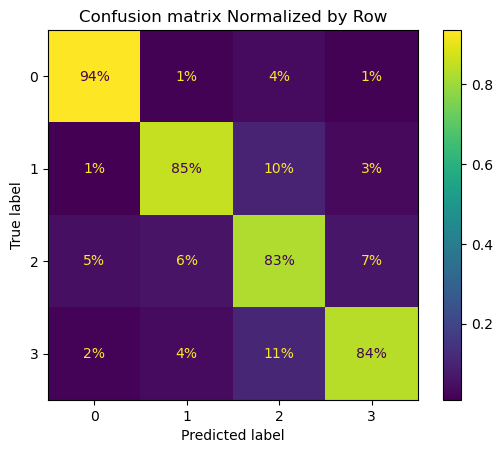

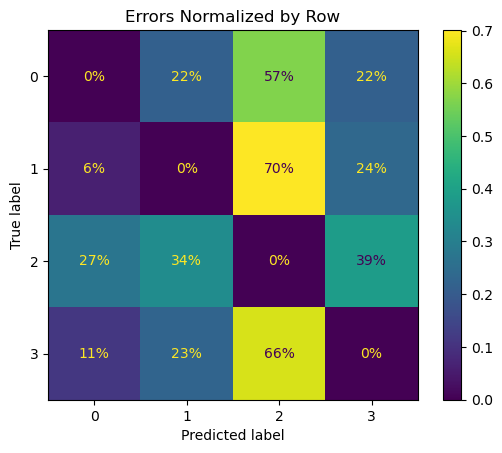

              precision    recall  f1-score   support

           0       0.97      0.94      0.95     91338
           1       0.71      0.85      0.78     12734
           2       0.89      0.83      0.86     49952
           3       0.42      0.84      0.56      4375

    accuracy                           0.89    158399
   macro avg       0.75      0.86      0.79    158399
weighted avg       0.91      0.89      0.90    158399



Validation Classification Report:


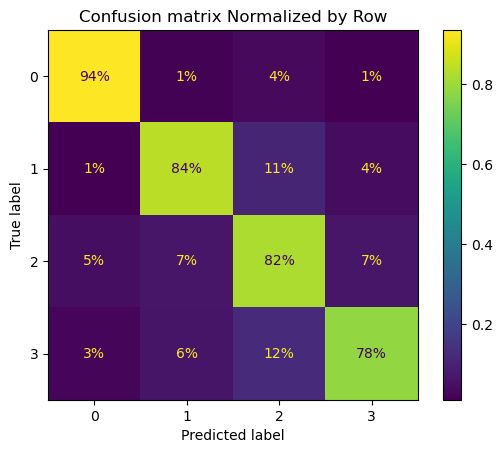

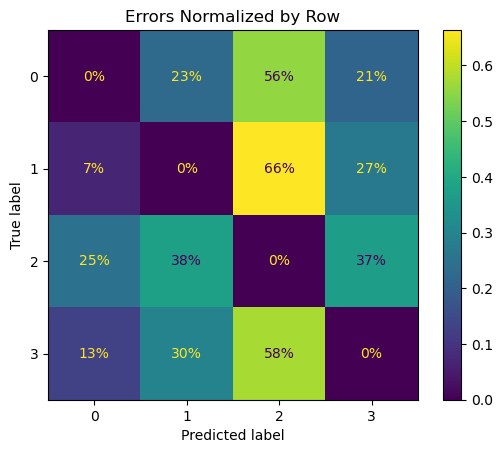

              precision    recall  f1-score   support

           0       0.97      0.94      0.95     22834
           1       0.68      0.84      0.75      3184
           2       0.89      0.82      0.85     12488
           3       0.40      0.78      0.53      1094

    accuracy                           0.89     39600
   macro avg       0.74      0.85      0.77     39600
weighted avg       0.91      0.89      0.89     39600



In [24]:
lgb_model = LGBMClassifier(
    class_weight={0:1, 1:2, 2:1, 3:5},   
    n_estimators=800,           
    learning_rate=0.04,          
    num_leaves=21,               
    max_depth=7,        
    feature_fraction=0.65,       
    bagging_fraction=0.75,
    bagging_freq=5,
    reg_alpha=2.0,               
    reg_lambda=4.0,              
    random_state=42,
    n_jobs=4,
    force_col_wise=True,
)

lgb_model.fit(
    X_train_transformed, y_train,
    eval_set=[(X_val_transformed, y_val)],
    callbacks=[lgb.early_stopping(stopping_rounds=30),
               lgb.log_evaluation(50)]
)

evaluate(classifier, X_train_transformed, y_train, X_val_transformed, y_val, train=False)

[LightGBM] [Warning] feature_fraction is set=0.65, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.65
[LightGBM] [Warning] bagging_fraction is set=0.75, subsample=1.0 will be ignored. Current value: bagging_fraction=0.75
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.65, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.65
[LightGBM] [Warning] bagging_fraction is set=0.75, subsample=1.0 will be ignored. Current value: bagging_fraction=0.75
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Info] Total Bins 256779
[LightGBM] [Info] Number of data points in the train set: 158399, number of used features: 1041
[LightGBM] [Info] Start training from score -0.725236
[LightGBM] [Info] Start training from score -2.002381
[LightGBM] [Info] Start training from score -1.328741


c:\Users\gsubh\miniforge3\envs\standard\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] feature_fraction is set=0.65, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.65
[LightGBM] [Warning] bagging_fraction is set=0.75, subsample=1.0 will be ignored. Current value: bagging_fraction=0.75
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5


c:\Users\gsubh\miniforge3\envs\standard\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] feature_fraction is set=0.65, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.65
[LightGBM] [Warning] bagging_fraction is set=0.75, subsample=1.0 will be ignored. Current value: bagging_fraction=0.75
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
Train Classification Report:


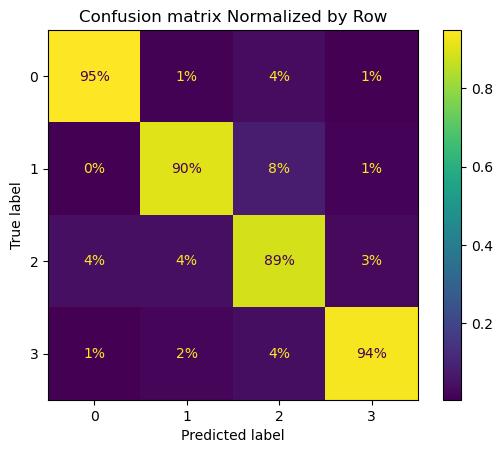

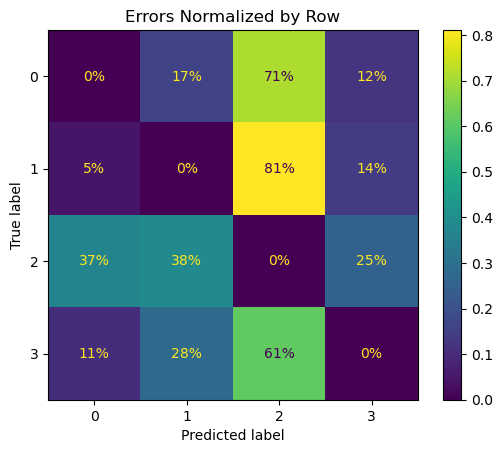

              precision    recall  f1-score   support

           0       0.98      0.95      0.96     91338
           1       0.79      0.90      0.84     12734
           2       0.91      0.89      0.90     49952
           3       0.65      0.94      0.77      4375

    accuracy                           0.92    158399
   macro avg       0.83      0.92      0.87    158399
weighted avg       0.93      0.92      0.93    158399



Validation Classification Report:


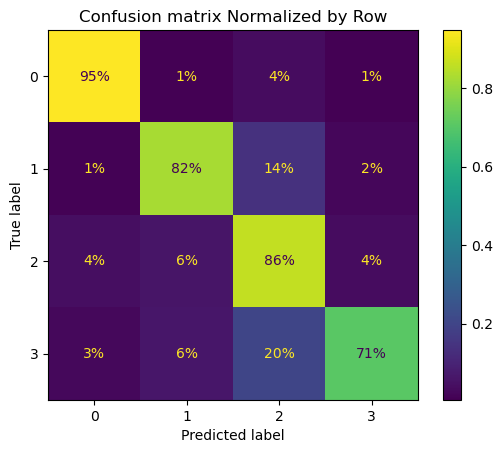

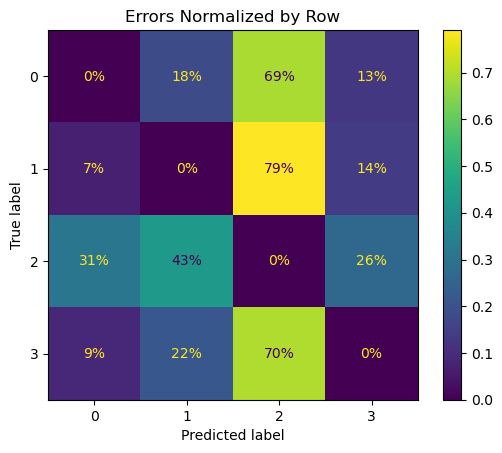

              precision    recall  f1-score   support

           0       0.97      0.95      0.96     22834
           1       0.72      0.82      0.77      3184
           2       0.88      0.86      0.87     12488
           3       0.53      0.71      0.60      1094

    accuracy                           0.90     39600
   macro avg       0.77      0.83      0.80     39600
weighted avg       0.91      0.90      0.91     39600



In [26]:
ensemble = VotingClassifier(
    estimators=[
        ('lr', classifier),
        ('lgb', lgb_model)
    ],
    voting='soft'
)

evaluate(ensemble, X_train_transformed, y_train, X_val_transformed, y_val, train=True)